# Code description
We take care of tau neutrino counts for the universal scenario = (multiple detectors)

## imports

In [1]:
import numpy as np
from sympy import sin, cos 
import sympy as sp
import scipy as scp
import pandas as pd
from cmath import *
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import scienceplots
plt.style.context(['science'])
plt.rcParams['text.usetex'] = True
plt.rcParams["font.family"] = "Times New Roman"
import pickle
import timeit
import glob # need to merge arrays
import os # need to make directory
from scipy.interpolate import interp1d
from scipy.integrate import quad

import ternary

print("Version", ternary.__version__)

t0 = timeit.default_timer()

Version 1.0.8


## universal tau_count

In [2]:
neuflux = pd.read_csv("neuflux_1505.04020/neuflux_SFR_proton_only.csv", 
                      header=None, names=["log10Enu", "rate"]) 

E_eV = 10**neuflux["log10Enu"].values
rate = neuflux["rate"].values   # already GeV/(cm^2 s sr)")

# Build interpolation function: input E (eV) 
flux_interp = interp1d(
    E_eV,
    rate,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e15  # eV
print(f"flux at E = {E_test:.1e} eV : {flux_interp(E_test):.3e} GeV/(cm^2 s sr)")

flux at E = 1.0e+15 eV : 1.674e-09 GeV/(cm^2 s sr)


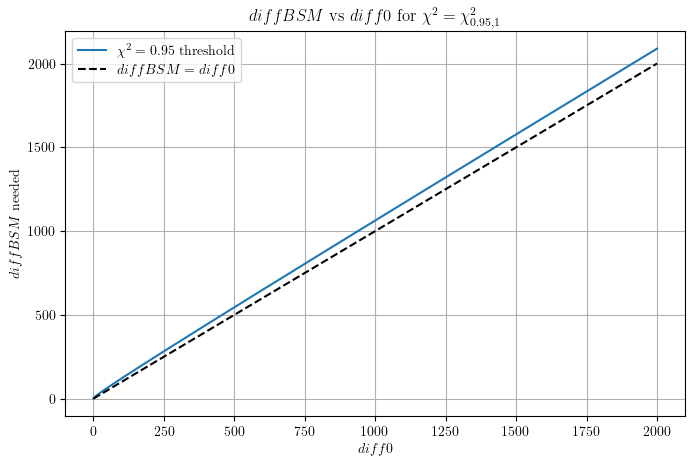

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.optimize import root_scalar

chi2_val = chi2.ppf(0.95, 1)

def target_func(diffBSM, diff0, chi2_target):
    return 2*(diffBSM - diff0 + diff0 * np.log(diff0/diffBSM)) - chi2_target

diff0_vals = np.linspace(0, 2000, 200)  # range of diff0
diffBSM_vals = []

for diff0 in diff0_vals:
    if diff0 == 0:
        diffBSM_vals.append(chi2_val / 2)
    else:
        sol = root_scalar(target_func, args=(diff0, chi2_val), bracket=[diff0, diff0*2])
        diffBSM_vals.append(sol.root)

plt.figure(figsize=(8,5))
plt.plot(diff0_vals, diffBSM_vals, label=r'$\chi^2 = 0.95$ threshold')
plt.plot(diff0_vals, diff0_vals, 'k--', label=r'$diffBSM = diff0$')
plt.xlabel(r'$diff0$')
plt.ylabel(r'$diffBSM$ needed')
plt.title(r'$diffBSM$ vs $diff0$ for $\chi^2 = \chi^2_{0.95,1}$')
plt.legend()
plt.grid(True)
plt.show()


In [58]:
drange+['pess','mod','opt']

[4, 5, 6, 7, 8, ['pess', 'mod', 'opt'], 'pess', 'mod', 'opt']

In [3]:
# Define the integrand_flux_area
def integrand_flux_area_exp(E,exp):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    area_factor = 0
    if exp=='poemma':
        area_factor=poemma_area_interp(E)
    if exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E)
    if exp=='grand200k':
        area_factor=grand_area_interp(E)
      
    area_factor = np.maximum(area_factor, 0)
        
    return flux_interp(E) * area_factor * unit_refiner    # 1/(s)

In [4]:
poemma_area = pd.read_csv("eff_area/poemma_nutau_tau.csv", 
                      header=None, names=["log10Enu", "area"]) 
kmtocm = 1e5
E_eV = 10**poemma_area["log10Enu"].values
eff_area = poemma_area["area"].values * kmtocm**2   # cm^2 sr

poemma_area_interp = interp1d(
    E_eV,
    eff_area,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e17  # eV
print(f"area at E = {E_test:.1e} eV : {poemma_area_interp(E_test):.3e} cm^2 sr")

area at E = 1.0e+17 eV : 7.172e+08 cm^2 sr


In [5]:
grand200k_area = pd.read_csv("eff_area/grand_200k.csv", 
                      header=None, names=["log10Enu", "area"]) 

E_eV = 1e9*grand200k_area["log10Enu"].values
eff_area = grand200k_area["area"].values    # cm^2 
print(np.log10(min(E_eV)),np.log10(max(E_eV)))
grand_area_interp = interp1d(
    E_eV,
    eff_area,
    kind="linear",       # or "cubic" for smoother
    bounds_error=False,
    fill_value="extrapolate"
)

# ---- Test the interpolator ----
E_test = 1e17  # eV
print(f"area at E = {E_test:.1e} eV : {grand_area_interp(E_test):.3e} cm^2 sr")

16.999999999999996 20.0
area at E = 1.0e+17 eV : 7.475e+09 cm^2 sr


In [6]:
# --- IceCube Gen2 Radio effective area data (GeV, cm^2) ---
effareadata_ICgen2radio = [
    [10**7.5, 4.06024e6],
    [10**8.0, 4.06024e6],
    [10**8.5, 4.75677e7],
    [10**9.0, 2.99916e8],
    [10**9.5, 1.15092e9],
    [10**10.0, 3.11424e9],
    [10**10.5, 6.63344e9],
    [10**11.0, 1.21362e10],
    [10**11.5, 2.03881e10],
]

# --- Build interpolation in log-log space (E in eV, A in cm^2) ---
E_eV_list = 1e9 * np.array([x for x, _ in effareadata_ICgen2radio])
A_cm2_list = np.array([y for _, y in effareadata_ICgen2radio])
_area_interp = interp1d(np.log10(E_eV_list), np.log10(A_cm2_list), 
                        kind='linear', fill_value='extrapolate')

def ICgen2radio_area_interp(E_eV):
    """Effective area [cm^2] of IceCube Gen2 Radio vs energy [eV]."""

    E = np.asarray(E_eV)  # handles float or array input

    Emin = np.min(E_eV_list)
    Emax = np.max(E_eV_list)

    # Initialize output array
    out = np.zeros_like(E, dtype=float)

    # Valid energy region (boolean mask)
    mask = (E >= Emin) & (E <= Emax)

    # Interpolate only where valid
    out[mask] = 10 ** _area_interp(np.log10(E[mask]))

    # If original input was scalar, return scalar
    return out.item() if np.isscalar(E_eV) else out

# Example:
E_test = 1e19  # eV
print(f"A_eff({E_test:.2e} eV) = {ICgen2radio_area_interp(E_test)} cm^2")

A_eff(1.00e+19 eV) = 3114239999.999997 cm^2


In [7]:
# Integration limits in eV
E_min = 1e15      # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV
year = 365*24*3600

In [8]:
# Define the integrand_flux_area
def integrand_flux_area_exp(E,exp):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    area_factor = 0
    if exp=='poemma':
        area_factor=poemma_area_interp(E)
    if exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E)
    if exp=='grand200k':
        area_factor=grand_area_interp(E)
      
    area_factor = np.maximum(area_factor, 0)
        
    return flux_interp(E) * area_factor * unit_refiner    # 1/(s)

In [39]:
def experimental_factor(exp):
    if exp=='poemma':
        time_factor=5*year*0.2 # 0.2 for duty cycle
    elif exp=='ICgen2radio':
        time_factor=10*year
    elif exp=='grand200k':
        time_factor=10*year
        
    else:
        raise TypeError("experiment not found")

    return time_factor

experimental_factor('poemma')

31536000.0

In [34]:
# Define the integrand_flux_area
def integrand_flux_area_exp(E, exp, d, a_eff, c_eff, src_ratio):
    EnuGeV = E * 1e-9
    # flux = rate/E^2 = 1/(GeV cm^2 s sr)
    # area = cm^2 sr
    # flux * area = GeV^-1 s^-1
    unit_refiner = (1/EnuGeV**2 ) * 1e-9 
    #factor explanaton: 1/E^2, 1/GeV to 1/eV
    area_factor = 0
    if type(exp)!=str:
        raise TypeError("experiment is not string!")
        
    explist = ['poemma', 'ICgen2radio', 'grand200k']
    if exp=='poemma':
        area_factor=poemma_area_interp(E)
    elif exp=='ICgen2radio':
        area_factor=ICgen2radio_area_interp(E)
    elif exp=='grand200k':
        area_factor=grand_area_interp(E)
    else:
        raise TypeError(f"experiment not found, it must be on of {explist}")

    area_factor = np.maximum(area_factor, 0)

    dm21, dm31 = np.array([7.49e-5, 2.534e-3])*1e-18
    theta12, theta13, theta23 =  [np.arcsin(np.sqrt(0.303)), 
                                  np.arcsin(np.sqrt(0.02225)), 
                                  np.arcsin(np.sqrt(0.572))]

    delta = 197*np.pi/180

#     ftau_fraction = flavor_fraction(E, dm21, dm31, 
#               theta12, theta23, theta13, delta,
#               d, a_eff, c_eff,
#               src_ratio, flavor='tau')
    ftau_fraction = 1/3
    return flux_interp(E) * ftau_fraction * area_factor * unit_refiner    # 1/(s)

In [40]:
def tau_count(exp, d=0, a_eff=None, c_eff=None, src_ratio=[1,2,0]):
    E_min = 1e15        # 1 PeV = 1e15 eV
    E_max = 100e18      # 100 EeV = 1e20 eV
    # Perform the integral
    result, err = quad(integrand_flux_area_exp, 
                       E_min, E_max, 
                       args=(exp,d, a_eff, c_eff, src_ratio), 
                       limit=500, epsabs=0, epsrel=1e-4)

    return result * experimental_factor(exp)


In [42]:
tau_count('poemma'), tau_count('ICgen2radio'), tau_count('grand200k')

(13.091686429019509, 2.229566869450249, 669.1653922715213)

In [50]:
# Perform the integral
E_min = 1e15        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('poemma',0, None, None, [1,2,0]), 
                   limit=500, epsabs=0, epsrel=1e-4)


# tobs = 0.2*5 years, pg. 16 , https://arxiv.org/pdf/1902.11287
# full 360 degree i.e. 2pi azimuth # hence no factor 30/360
# 0.2 for duty cycle, 1/3 for tau flavor
print('poemma tau count:', np.round(result * 5*year*0.20/3, 3) )

poemma tau count: 4.364


In [48]:
# Integration limits in eV
E_min = 1e15 #1e18        # 1 PeV = 1e15 eV
E_max = 100e18      # 100 EeV = 1e20 eV

result, err = quad(integrand_flux_area_exp, 
                   E_min, E_max, 
                   args=('grand200k',0, None, None, [1,2,0]), 
                   limit=500, epsabs=0, epsrel=1e-4)

print('POEMMA paper --> grand tau count:', np.round(result * 10*year, 3) )

POEMMA paper --> grand tau count: 669.165


In [51]:
print(f"A_eff at {E_test:.2e} eV:  \nPOEMMA = {poemma_area_interp(E_test)} cm^2 sr",
    f"\nGRAND = {grand_area_interp(E_test)} cm^2",
    f"\nIC-gen2 radio = {ICgen2radio_area_interp(E_test)} cm^2")


A_eff at 1.00e+19 eV:  
POEMMA = 142436829417.77667 cm^2 sr 
GRAND = 376953913427.635 cm^2 
IC-gen2 radio = 3114239999.999997 cm^2
